Regiones y Fronteras

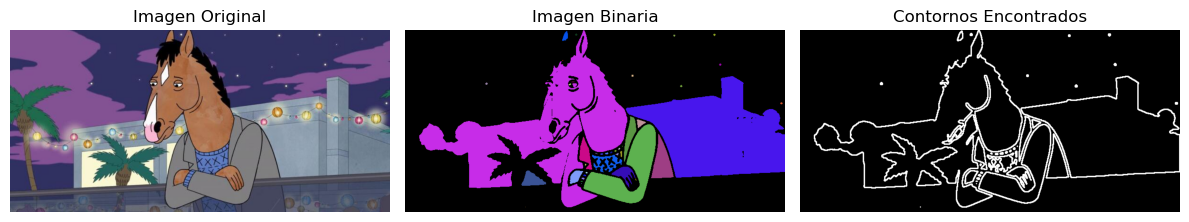

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('imagen1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) #siempre convertir a escala de grises
#combiar tecnicas para preparar la imagen 
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_,binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#encontramos las regiones 
num_l, label = cv2.connectedComponents(binary)
#identificar por colores 
color = np.random.randint(0, 255, size=(num_l, 3), dtype=np.uint8)
#fondo negro
color[0] = [0, 0, 0]
colorear = color[label]
#encontrar fronteras
contornos,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_fin = cv2.drawContours(np.zeros_like(gray), contornos, -1, 255,2)

plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.subplot(1, 3, 2)
plt.title('Imagen Binaria')
plt.imshow(colorear)
plt.axis('off')
plt.subplot(1, 3, 3)
plt.title('Contornos Encontrados')
plt.imshow(contorno_fin, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()


Conteo

Número de elementos encontrados: 650


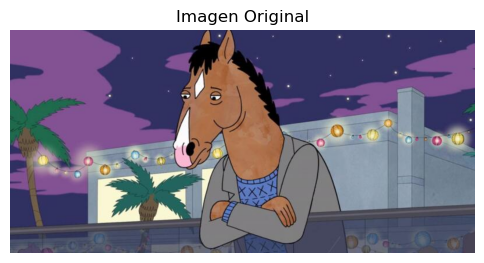

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar_elementos(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,binary = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)

    e_img = measure.label(binary, connectivity=2) 
    #2 = conectividad es de 4 elementos( arriba, abajo, izquierda, derecha) 
    #cuando es 1 es de 8 elementos (arriba, abajo, izquierda, derecha y las diagonales)
    num_obj = np.max(e_img)
    return num_obj

image = cv2.imread('imagen1.jpg')
num_elementos = contar_elementos(image)
print(f'Número de elementos encontrados: {num_elementos}')

#mostrar imagen
plt.figure(figsize=(6, 6))
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


Total regiones: 41

region 1:
  - Numero de pixeles: 49350
  - Cantidad de colores distintos: 128
  - Color promedio (BGR): [130, 144, 168]

region 2:
  - Numero de pixeles: 158
  - Cantidad de colores distintos: 8
  - Color promedio (BGR): [80, 116, 169]

region 3:
  - Numero de pixeles: 17
  - Cantidad de colores distintos: 8
  - Color promedio (BGR): [189, 166, 166]

region 4:
  - Numero de pixeles: 17
  - Cantidad de colores distintos: 10
  - Color promedio (BGR): [188, 163, 164]

region 5:
  - Numero de pixeles: 14
  - Cantidad de colores distintos: 5
  - Color promedio (BGR): [201, 178, 178]

region 6:
  - Numero de pixeles: 3
  - Cantidad de colores distintos: 2
  - Color promedio (BGR): [90, 115, 159]

region 7:
  - Numero de pixeles: 17
  - Cantidad de colores distintos: 9
  - Color promedio (BGR): [185, 161, 165]

region 8:
  - Numero de pixeles: 16
  - Cantidad de colores distintos: 5
  - Color promedio (BGR): [193, 170, 171]

region 9:
  - Numero de pixeles: 41489
  - Canti

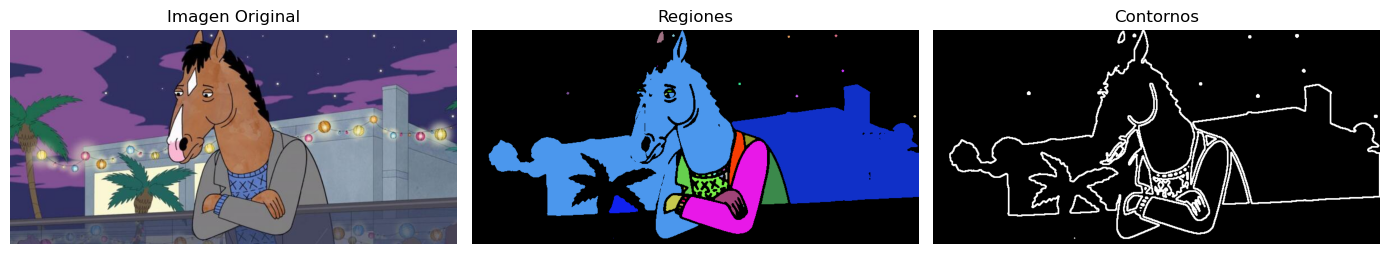

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

img = cv2.imread('imagen1.jpg')
if img is None:
    raise FileNotFoundError("imagen1.jpg no encontrada. Coloca la imagen en el mismo directorio del notebook.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

labels = measure.label(binary, connectivity=2)
num_regiones = int(np.max(labels))
print(f"Total regiones: {num_regiones}")

# region
for i in range(1, num_regiones + 1):
    mask = (labels == i)
    num_pixels = int(np.sum(mask))
    region_pixels = img[mask]
    if region_pixels.size == 0:
        continue
    avg_color = np.mean(region_pixels, axis=0).astype(int)
    region_pixels_reduced = (region_pixels // 32) * 32
    unique_colors = np.unique(region_pixels_reduced.reshape(-1, 3), axis=0)
    num_colores = len(unique_colors)

    print(f"\nregion {i}:")
    print(f"  - Numero de pixeles: {num_pixels}")
    print(f"  - Cantidad de colores distintos: {num_colores}")
    print(f"  - Color promedio (BGR): {avg_color.tolist()}")

# Conteo colores
img_q = (img // 32) * 32
pixels = img_q.reshape(-1, 3)
colors_u, counts = np.unique(pixels, axis=0, return_counts=True)
order = np.argsort(-counts)

print("\nConteo de colores en imagen:")
for idx in order:
    c = colors_u[idx]
    cnt = int(counts[idx])
    r, g, b = int(c[2]), int(c[1]), int(c[0])
    if cnt == 0:
        continue
    print(f"color {r}, {g}, {b} objetos {cnt}")


colors_map = np.random.randint(0, 255, size=(num_regiones + 1, 3), dtype=np.uint8)
colors_map[0] = [0, 0, 0]
colored_img = colors_map[labels]

binary_u8 = (binary > 0).astype('uint8') * 255
contours, _ = cv2.findContours(binary_u8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contour_img = cv2.drawContours(np.zeros_like(img), contours, -1, (255, 255, 255), 2)

plt.figure(figsize=(14,5))
plt.subplot(1,3,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title('Regiones')
plt.imshow(colored_img)
plt.axis('off')

plt.subplot(1,3,3)
plt.title('Contornos')
plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()